In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import seaborn as sns


In [15]:
# Cleaning the Dataset
df = pd.read_csv("movies.csv")
df = df.dropna(subset=["Gross"])
df = df.dropna(subset=["Certificate"])
df = df.dropna(subset=["Meta_score"])
df["Gross"] = df["Gross"].str.replace(",", "")
df["Gross"] = pd.to_numeric(df["Gross"])
def classify_movie(gross):
    if gross > 100_000_000:
        return "Hit"
    elif gross > 30_000_000:
        return "Average"
    else:
        return "Flop"

df["Gross"] = df["Gross"].apply(classify_movie)
df.head(2)

,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,No_of_Votes,Gross
0,1994,A,142,Drama,9.3,80.0,2343110,Flop
1,1972,A,175,"Crime, Drama",9.2,100.0,1620367,Hit


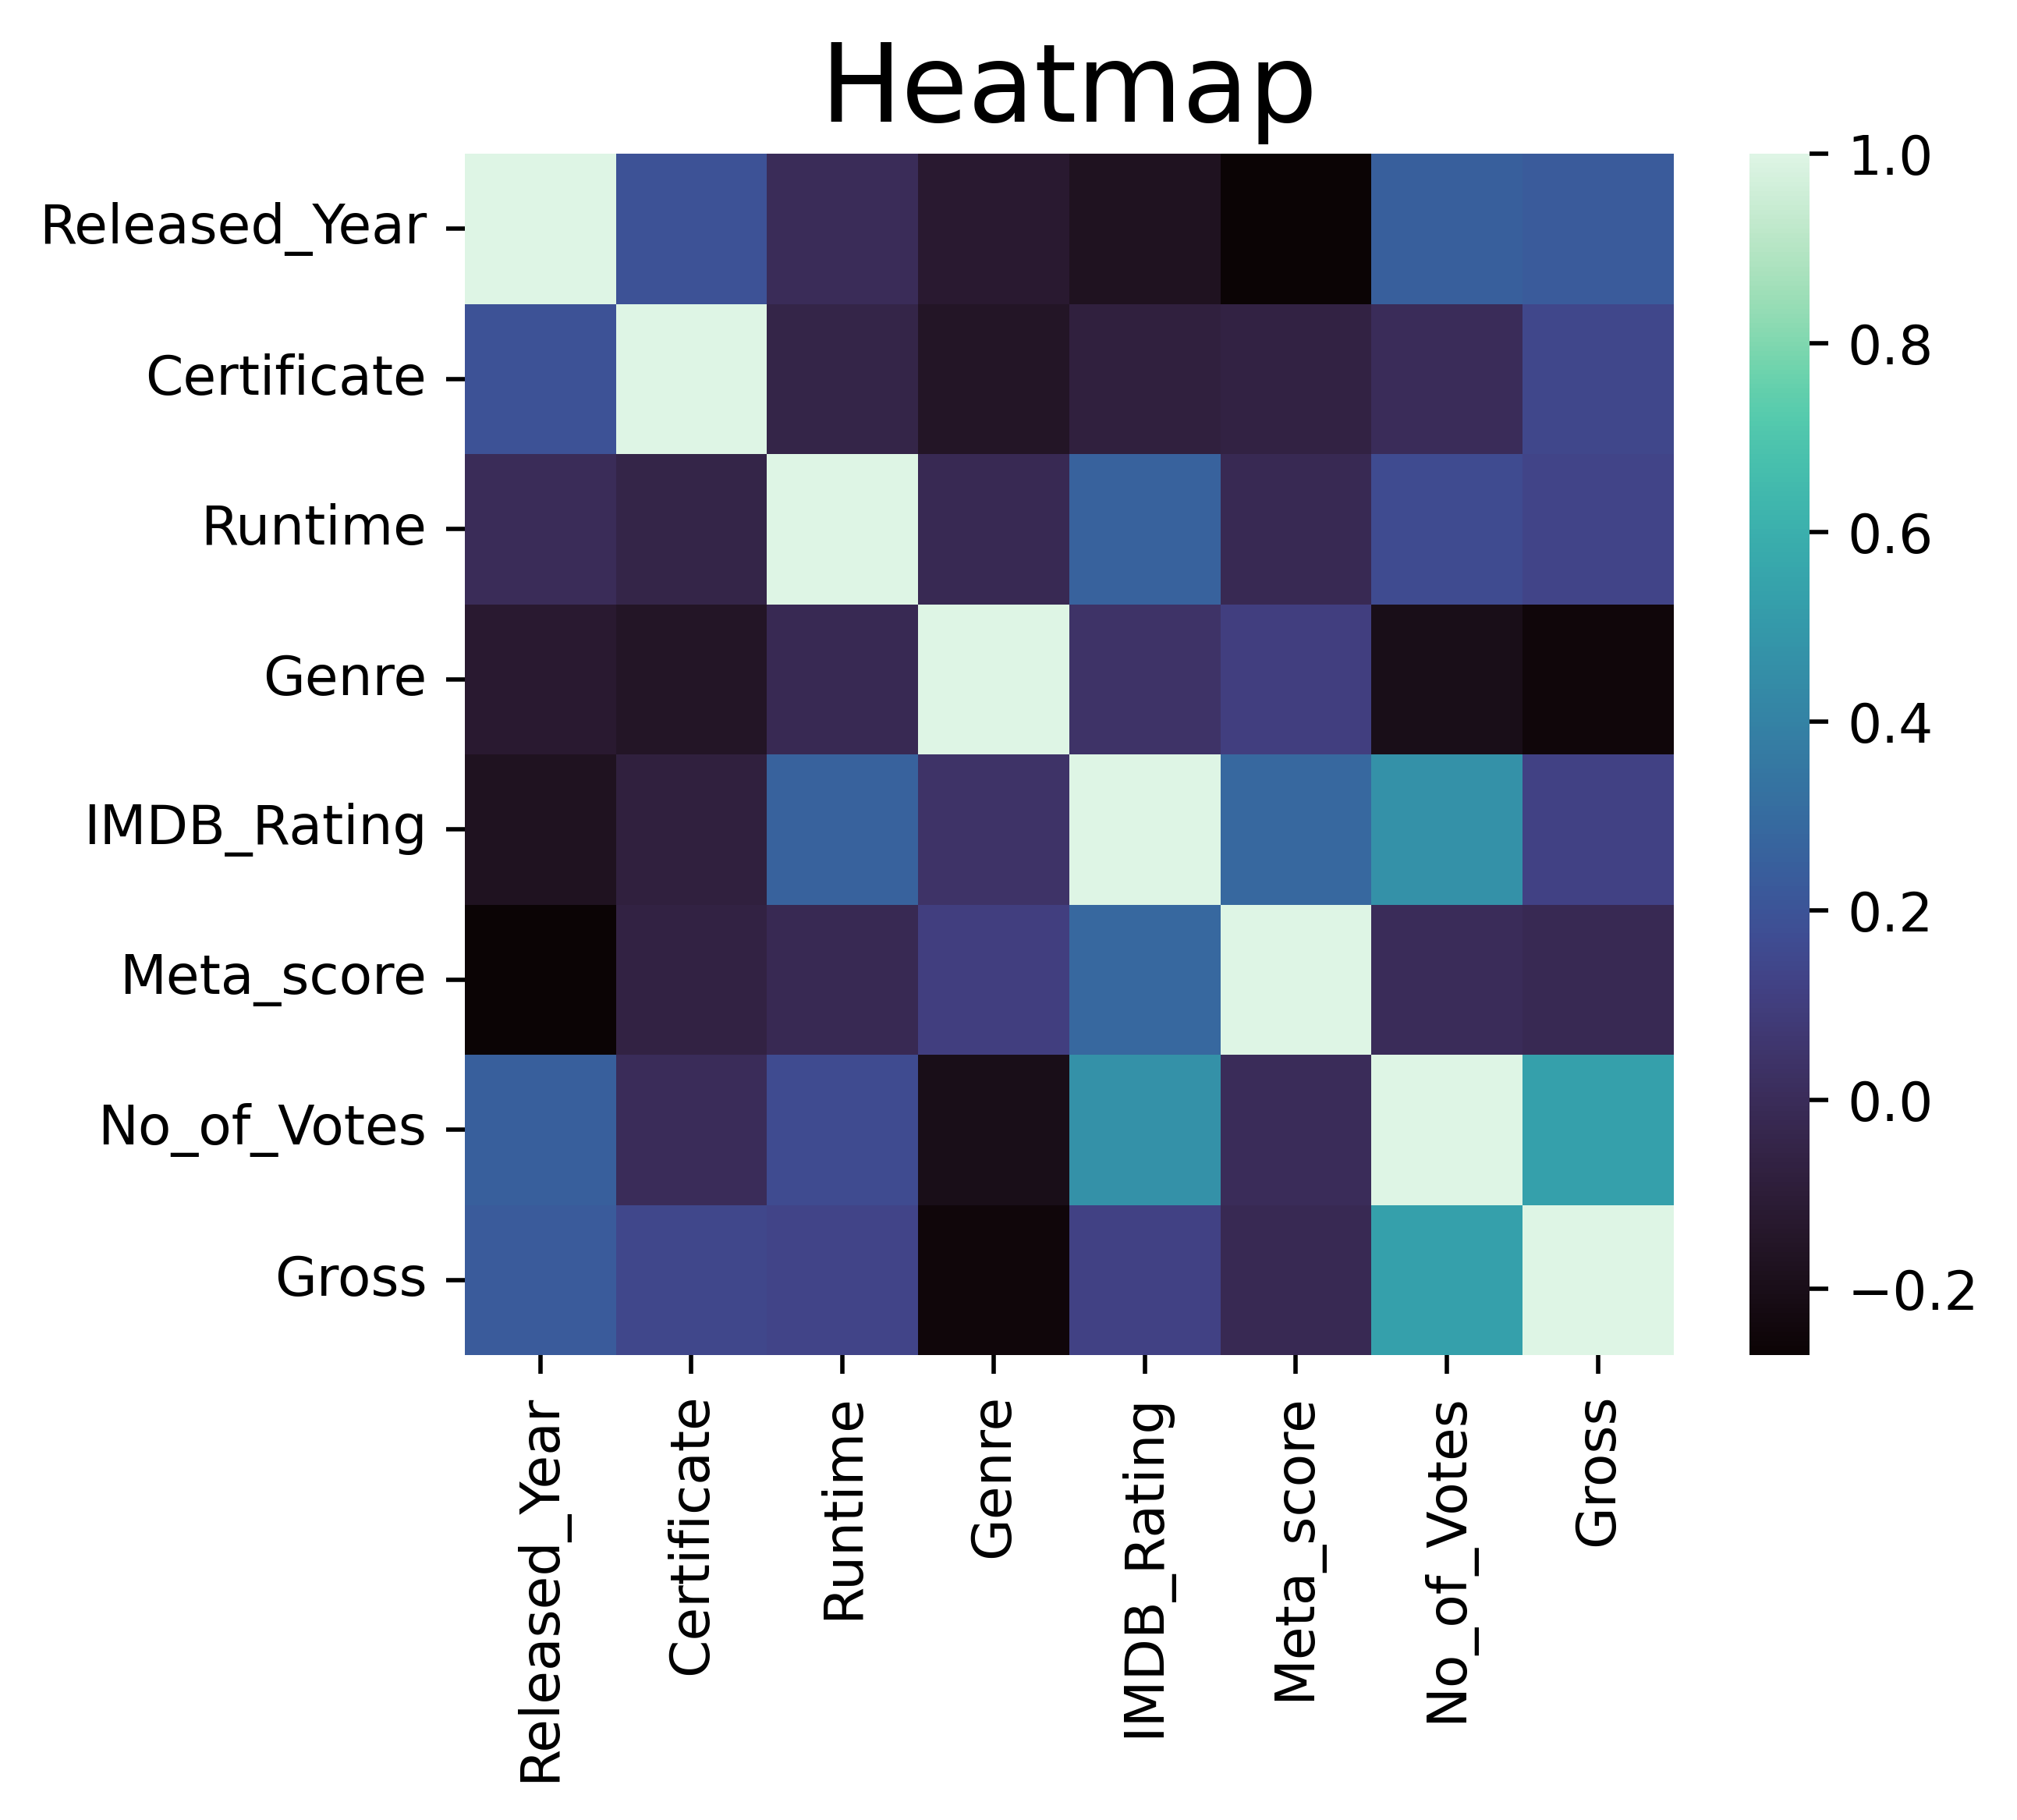

In [31]:
# Heatmap

df_encoded = df.copy()

le = LabelEncoder()

for col in ["Released_Year", "Certificate", "Runtime", "Genre", "IMDB_Rating", "Meta_score", "No_of_Votes"]:
    df_encoded[col] = le.fit_transform(df_encoded[col])


skill_map = {"Hit": 2, "Average": 1, "Flop": 1}
for col in ["Gross"]:
    df_encoded[col] = df_encoded[col].map(skill_map)

plt.figure(figsize=(5,4), dpi=500)
sns.heatmap(df_encoded.corr(), cmap="mako")
plt.title("Heatmap", fontdict={'fontsize': 20})
plt.savefig("images/heatmap.png", bbox_inches='tight')
plt.show()


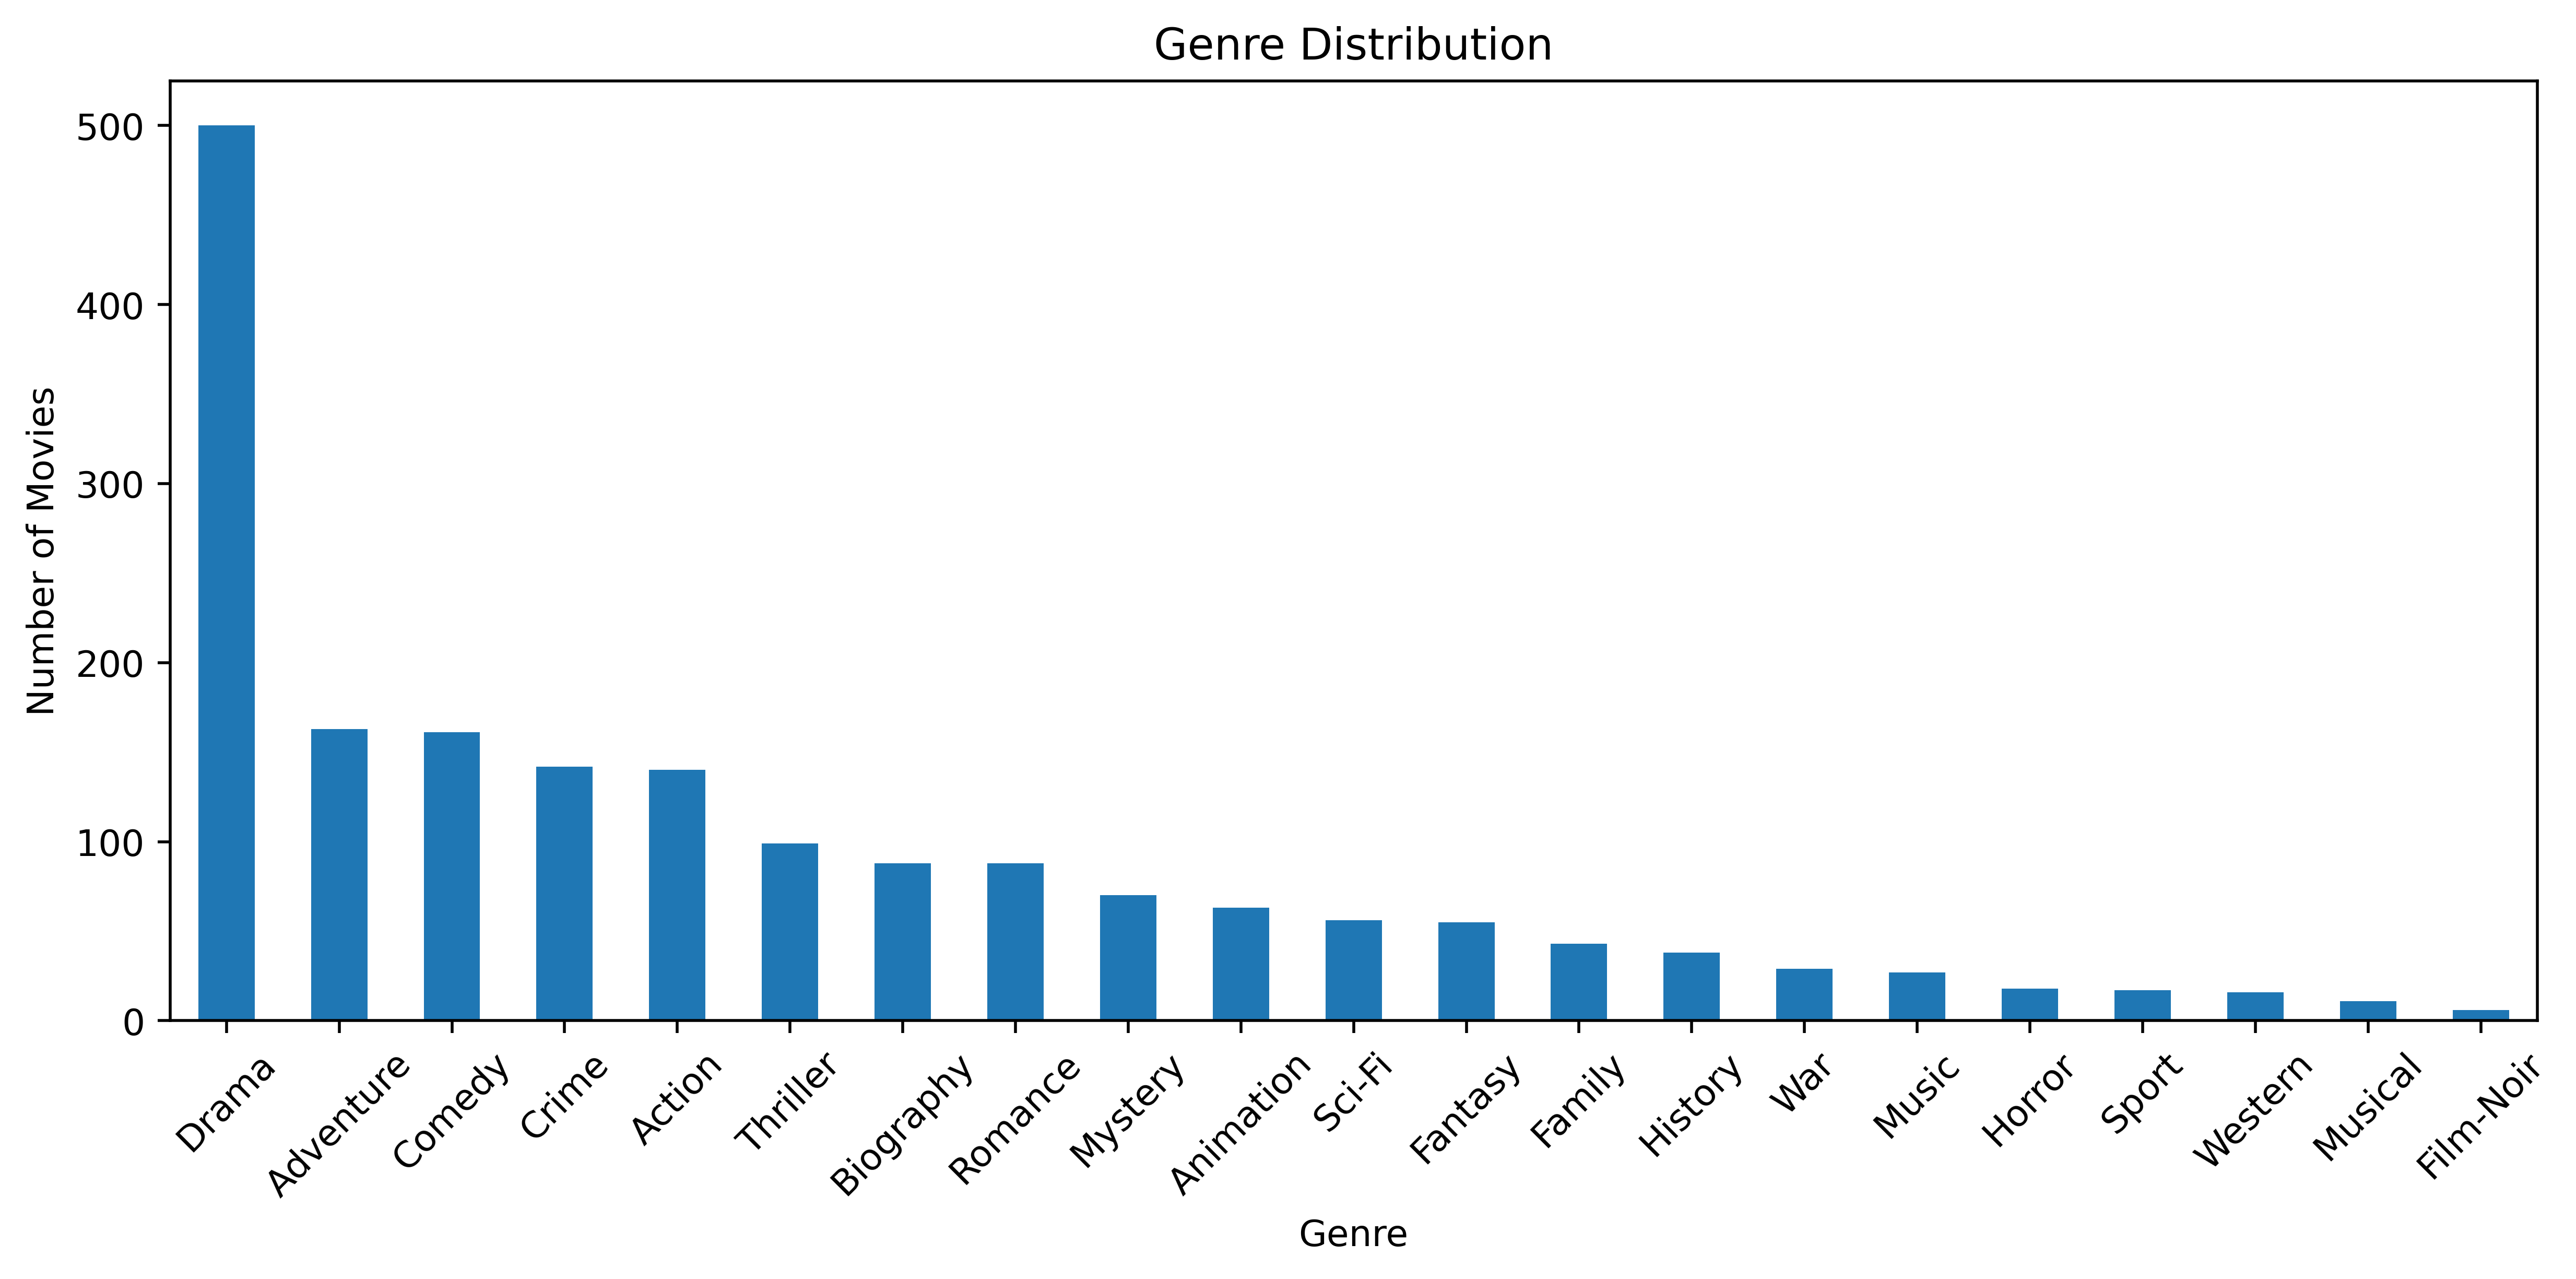

In [49]:
#Genre Distribution
all_genres = df['Genre'].dropna().str.split(',').explode().str.strip()

genre_counts = all_genres.value_counts()

plt.figure(figsize=(10,5), dpi=500)
genre_counts.plot(kind='bar')
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/genre-distribution.png", bbox_inches='tight')
plt.show()

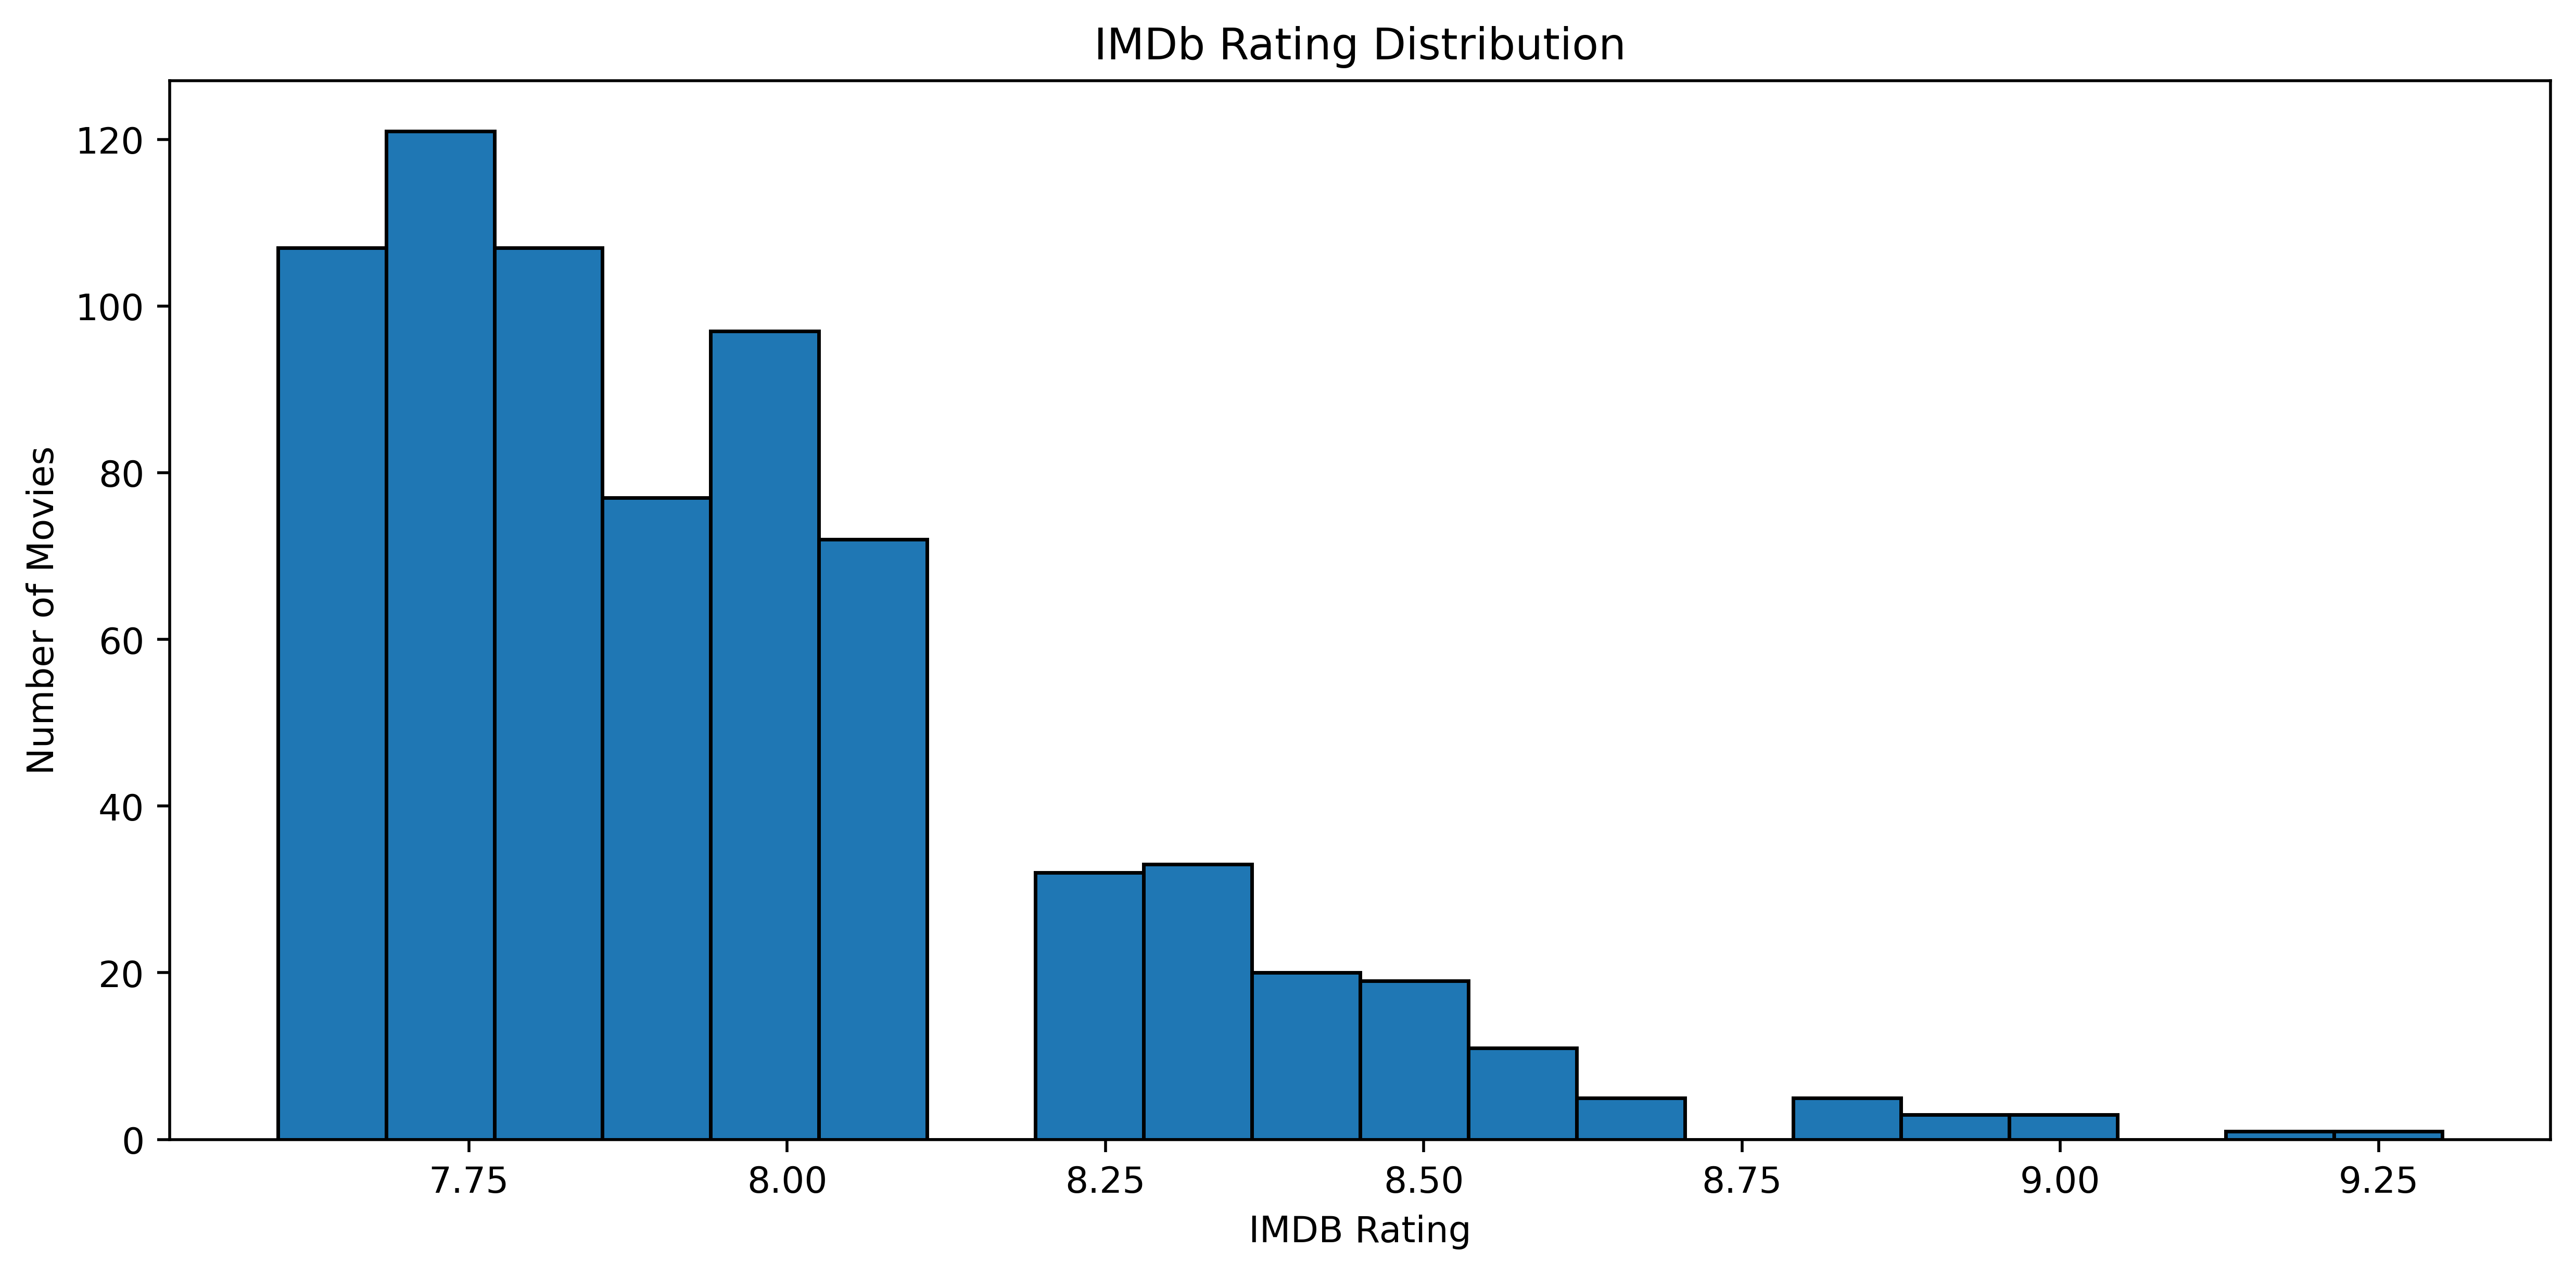

In [47]:
# IMDB Rating distribution
plt.figure(figsize=(10, 5), dpi=500)
plt.hist(df['IMDB_Rating'].dropna(), bins=20, edgecolor='black')
plt.title("IMDb Rating Distribution")
plt.xlabel("IMDB Rating")
plt.ylabel("Number of Movies")
plt.tight_layout()

plt.savefig("images/imdb-ratings.png", dpi=500, bbox_inches='tight')
plt.show()

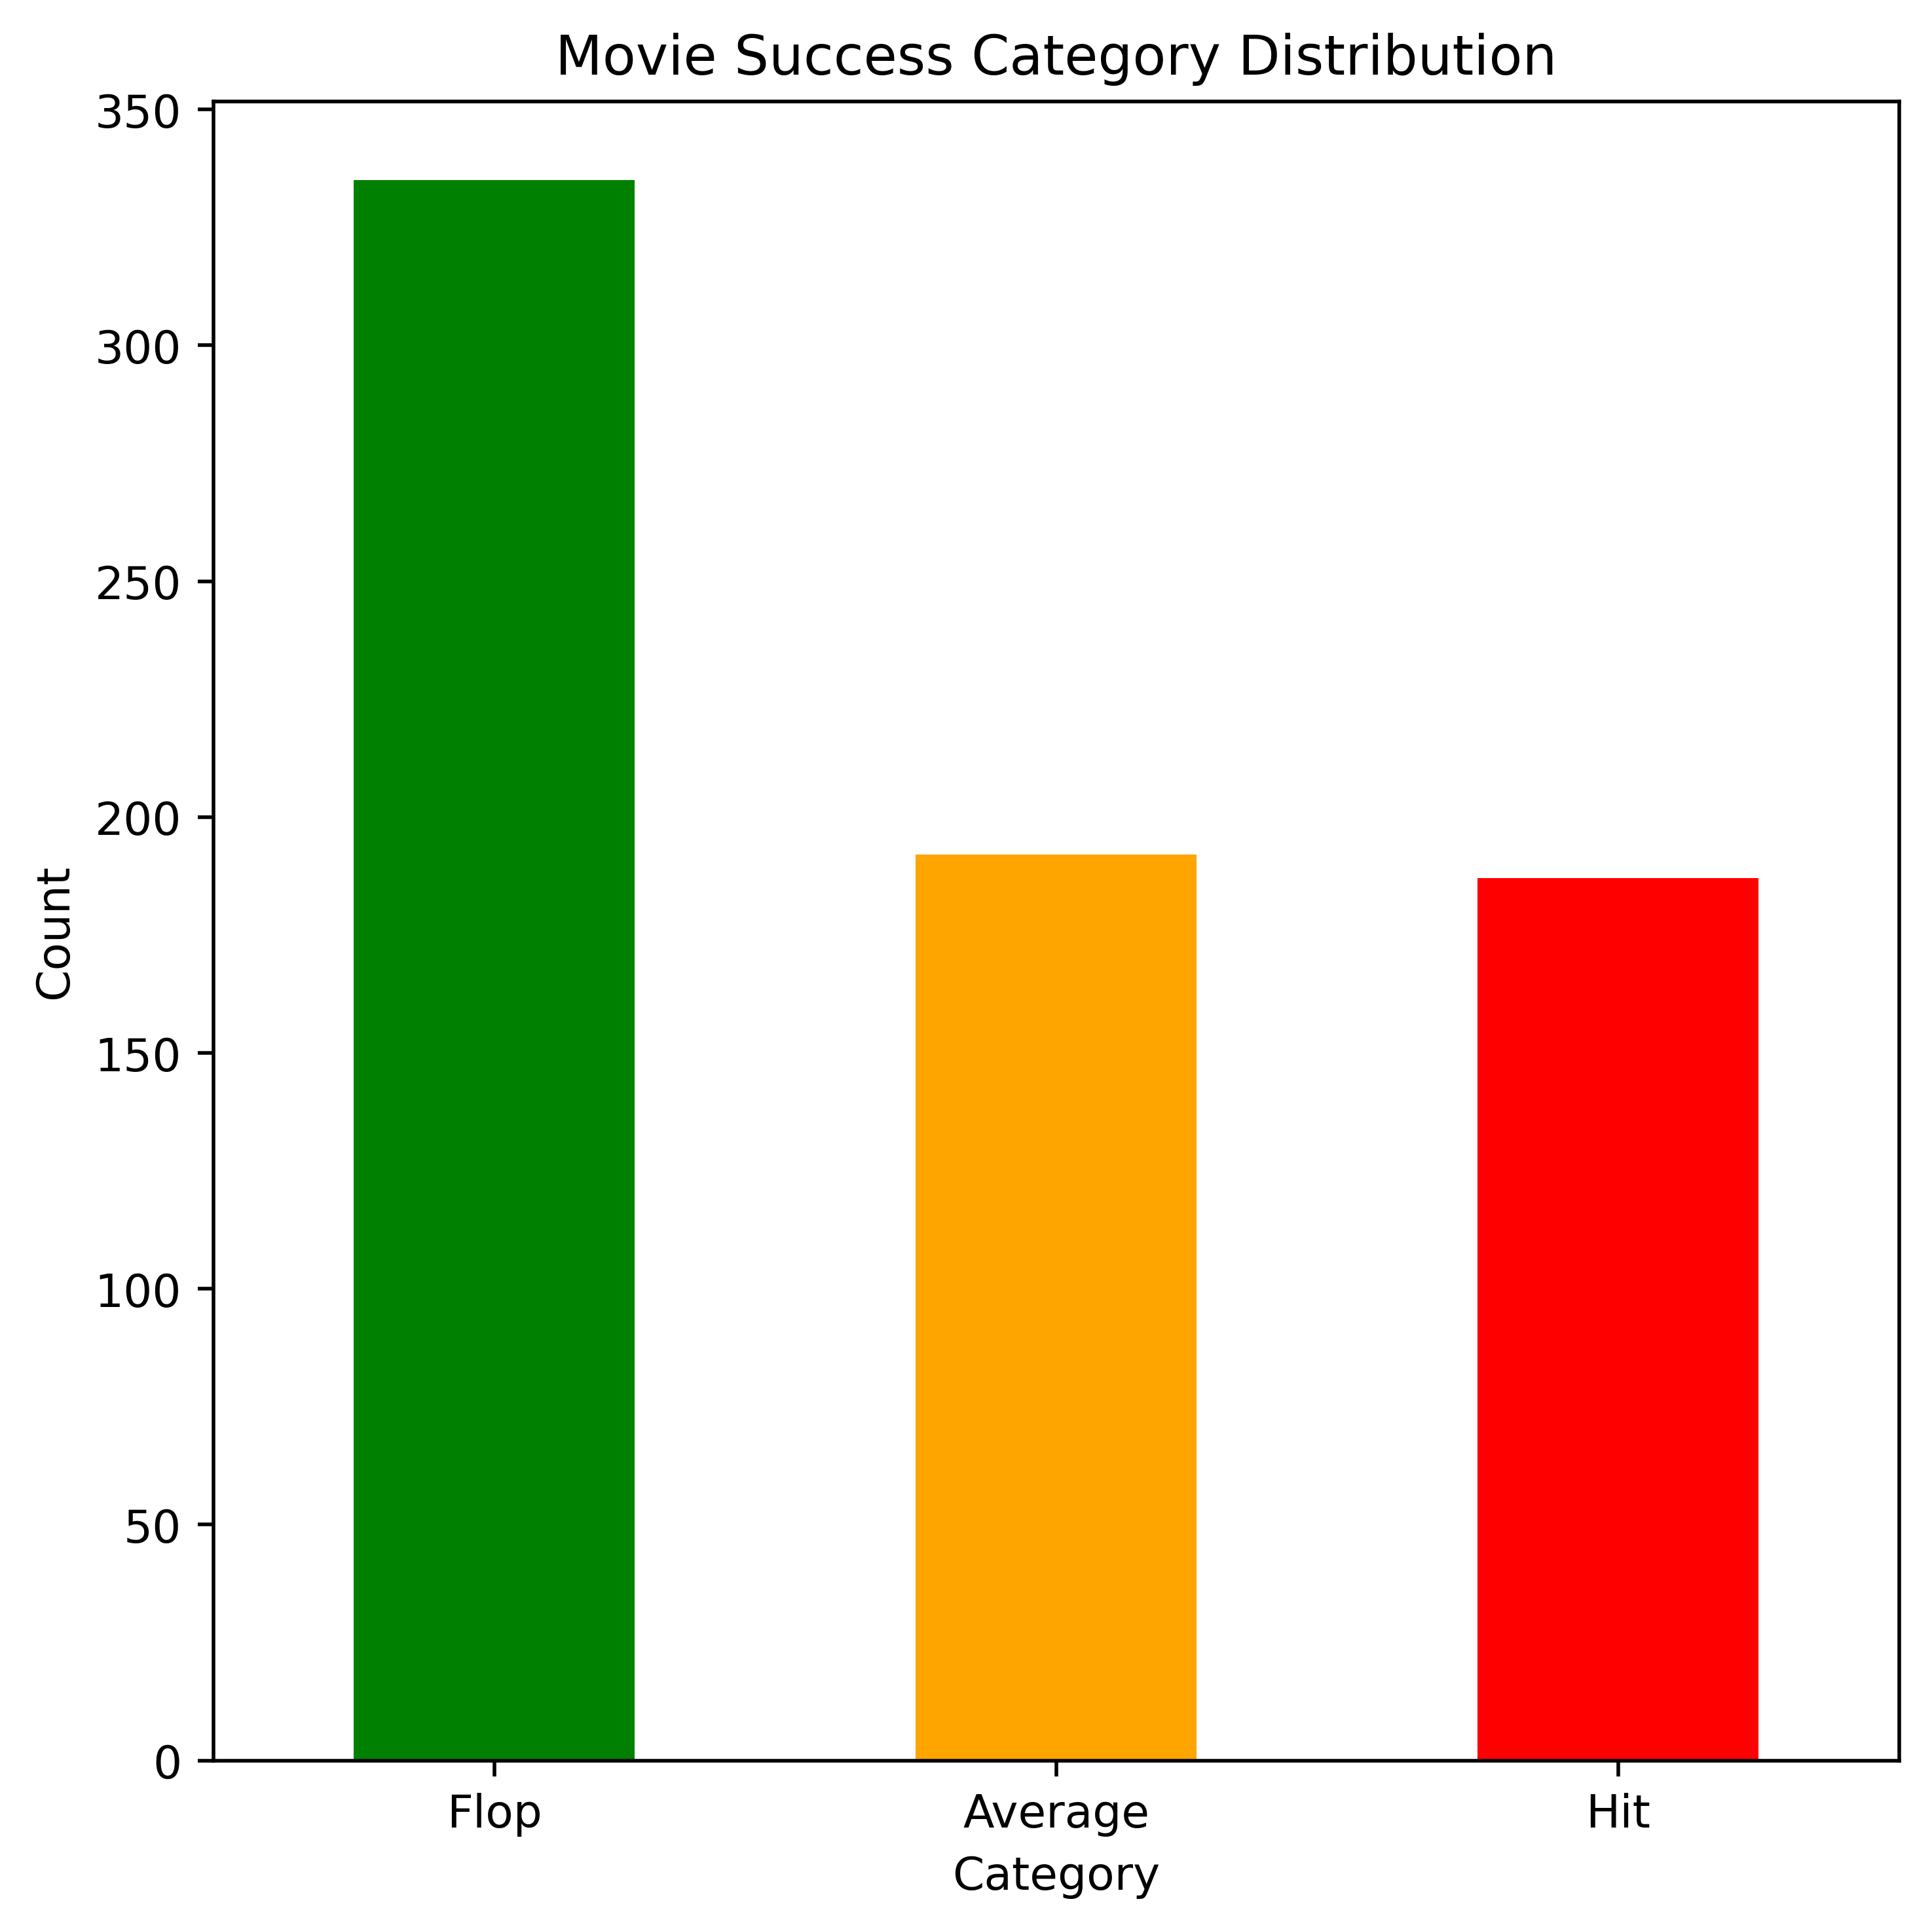

In [50]:
# Movie Success Category Distribution
success_counts = df['Gross'].value_counts()

plt.figure(figsize=(6, 6), dpi=500)
success_counts.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title("Movie Success Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("images/success-distribution.png", bbox_inches='tight')
plt.show()